In [1]:
from astropy.io import fits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.stats as st
from scipy.interpolate import interp1d
from stis_extract import *

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/CONTACT/STIS/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

# Latest visit

In [5]:
qso_name = 'J2339-5523'

In [6]:
d_latest = coadd_1dspec(qso_name, ['OF8G51010', 'OF8G51020', 'OF8G51030'], 4)

/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:337: RuntimeWarning: invalid value encountered in divide
  net_ct_rates_stitch = net_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:338: RuntimeWarning: divide by zero encountered in divide
  err_u_ct_rates_stitch = err_u_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:338: RuntimeWarning: invalid value encountered in divide
  err_u_ct_rates_stitch = err_u_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:339: RuntimeWarning: invalid value encountered in divide
  err_d_ct_rates_stitch = err_d_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:340: RuntimeWarning: divide by zero encountered in divide
  err_ct_rates_stitch = err_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extrac

All visits

In [7]:
d_prev = coadd_1dspec(qso_name,
                    ['OF8G53010', 'OF8G53020'],
                     4)

Compare

In [8]:
flux_prev_interp = interp1d(d_prev['wave'], d_prev['flux'], fill_value='extrapolate')(d_latest['wave'])
err_prev_interp = np.sqrt(interp1d(d_prev['wave'], d_prev['error']**2, fill_value='extrapolate')(d_latest['wave']))

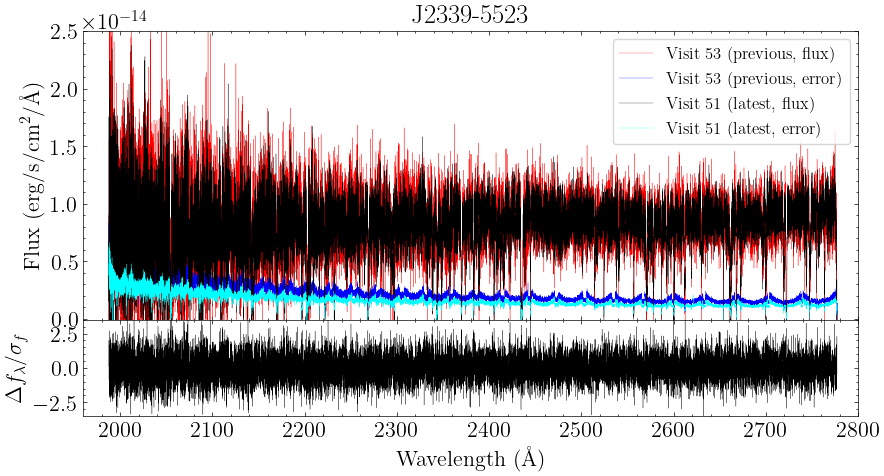

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(d_prev['wave'], d_prev['flux'], where='mid', color='red', alpha=1, lw=.2, label="Visit 53 (previous, flux)")
axes[0].step(d_prev['wave'], d_prev['error'], where='mid', color='blue', alpha=1, lw=.2, label="Visit 53 (previous, error)")

axes[0].step(d_latest['wave'], d_latest['flux'], where='mid', color='black', alpha=1, lw=.2, label="Visit 51 (latest, flux)")
axes[0].step(d_latest['wave'], d_latest['error'], where='mid', color='cyan', alpha=1, lw=.2, label="Visit 51 (latest, error)")

axes[0].set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')
axes[0].set_title(r'J2339-5523')

axes[0].legend(loc='upper right')
axes[0].set_xlim(1960,2800)
axes[0].set_ylim(-1e-16,2.5e-14)
axes[0].legend()

axes[1].step(d_latest['wave'], (d_latest['flux']-flux_prev_interp)/np.sqrt(d_latest['error']**2+err_prev_interp**2), 
             alpha=1,lw=.2, color='black')

axes[1].set_ylabel(r'$\Delta f_\lambda / \sigma_f$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-3.5, 3.5)
plt.subplots_adjust(wspace=0.2, hspace=0)

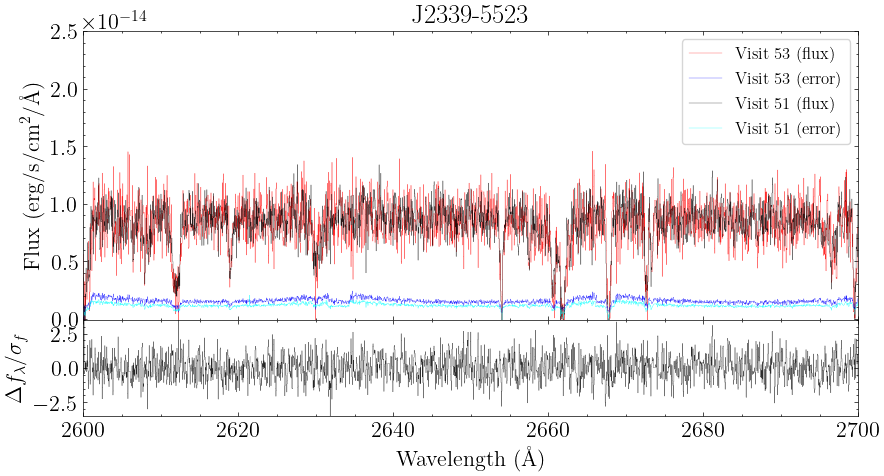

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)


axes[0].step(d_prev['wave'], d_prev['flux'], where='mid', color='red', alpha=1, lw=.2, label="Visit 53 (flux)")
axes[0].step(d_prev['wave'], d_prev['error'], where='mid', color='blue', alpha=1, lw=.2, label="Visit 53 (error)")

axes[0].step(d_latest['wave'], d_latest['flux'], where='mid', color='black', alpha=1, lw=.2, label="Visit 51 (flux)")
axes[0].step(d_latest['wave'], d_latest['error'], where='mid', color='cyan', alpha=1, lw=.2, label="Visit 51 (error)")

axes[0].set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')
axes[0].set_title(r'J2339-5523')

axes[0].legend(loc='upper right')
axes[0].set_xlim(2600,2700)
axes[0].set_ylim(-1e-16,2.5e-14)
axes[0].legend()

axes[1].step(d_latest['wave'], (d_latest['flux']-flux_prev_interp)/np.sqrt(d_latest['error']**2+err_prev_interp**2), 
             alpha=1,lw=.2, color='black')

axes[1].set_ylabel(r'$\Delta f_\lambda / \sigma_f$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-3.5, 3.5)
plt.subplots_adjust(wspace=0.2, hspace=0)

# Co-add

In [10]:
d_all = coadd_1dspec(qso_name,
                    ['OF8G53010', 'OF8G53020',
                     'OF8G51010', 'OF8G51020', 'OF8G51030'],
                     4)

/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:337: RuntimeWarning: invalid value encountered in divide
  net_ct_rates_stitch = net_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:338: RuntimeWarning: divide by zero encountered in divide
  err_u_ct_rates_stitch = err_u_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:338: RuntimeWarning: invalid value encountered in divide
  err_u_ct_rates_stitch = err_u_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:339: RuntimeWarning: invalid value encountered in divide
  err_d_ct_rates_stitch = err_d_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:340: RuntimeWarning: divide by zero encountered in divide
  err_ct_rates_stitch = err_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extrac

In [11]:
flux_all_interp = interp1d(d_all['wave'], d_all['flux'], fill_value='extrapolate')(d_latest['wave'])
err_all_interp = np.sqrt(interp1d(d_all['wave'], d_all['error']**2, fill_value='extrapolate')(d_latest['wave']))

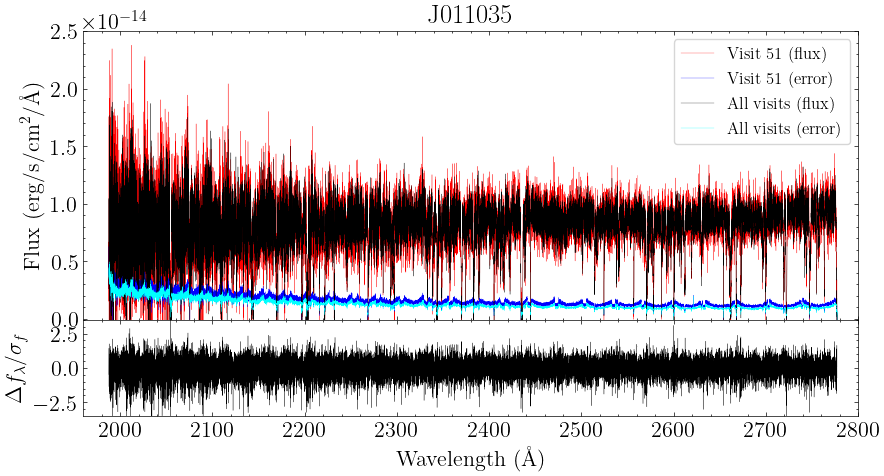

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(d_latest['wave'], d_latest['flux'], where='mid', color='red', alpha=1, lw=.2, label="Visit 51 (flux)")
axes[0].step(d_latest['wave'], d_latest['error'], where='mid', color='blue', alpha=1, lw=.2, label="Visit 51 (error)")

axes[0].step(d_all['wave'], d_all['flux'], where='mid', color='black', alpha=1, lw=.2, label="All visits (flux)")
axes[0].step(d_all['wave'], d_all['error'], where='mid', color='cyan', alpha=1, lw=.2, label="All visits (error)")

axes[0].set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')
axes[0].set_title(r'J011035')

axes[0].legend(loc='upper right')
axes[0].set_xlim(1960,2800)
axes[0].set_ylim(-1e-16,2.5e-14)
axes[0].legend()

axes[1].step(d_latest['wave'], (d_latest['flux']-flux_all_interp)/np.sqrt(d_latest['error']**2+err_all_interp**2), 
             alpha=1,lw=.2, color='black')

axes[1].set_ylabel(r'$\Delta f_\lambda / \sigma_f$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-3.5, 3.5)
plt.subplots_adjust(wspace=0.2, hspace=0)

## Flux calculation

In [13]:
idx = d_all['wave']<2730

flux_lam_ref = 3631/(3.34*1e4*d_all['wave'][idx]**2)
dwav = d_all['wave'][idx][1:]-d_all['wave'][idx][:-1]
wav_int = .5*(d_all['wave'][idx][1:]+d_all['wave'][idx][:-1])
f_int = .5*(d_all['flux'][idx][1:]+d_all['flux'][idx][:-1])
f_ref_int = .5*(flux_lam_ref[1:]+flux_lam_ref[:-1])

In [14]:
mag = -2.5*np.log10(np.nansum(wav_int*f_int*dwav)/np.nansum(wav_int*f_ref_int*dwav))

In [15]:
mag

15.987939482416424

Convert back to flux using pivot wavelength

In [16]:
for i in range(len(d_all['flux'])):
    
    if ~np.isnan(d_all['flux'][i]):
        w0 = d_all['wave'][i]
        break

In [17]:
w1 = 2730

In [18]:
wav_p = np.sqrt((w1-w0)/(w0**-1 - w1**-1))

In [19]:
f_lam_nuv = (3631*10**(-mag/2.5))/(3.34e4*wav_p**2)

In [20]:
f_lam_nuv

8.064439161364209e-15

## Plotabs conversion

In [21]:
idx = (~np.isnan(d_all['flux']))&(~np.isnan(d_all['error']))

In [22]:
save_spec1d_fits(rootdir+'J2339-5523/', 'J2339_es=4', d_all)